## Pregunta 3

In [2]:
import pandas as pd

file_path = "/Users/danielmorantes/PythonP/Analítica_Comp_Uniandes/Proyecto2_AnalComp/EDA/data_encoded.csv"

df = pd.read_csv(file_path)
print("Column names:")
print(df.columns.tolist())
df.shape

Column names:
['periodo', 'cole_area_ubicacion', 'cole_bilingue', 'cole_caracter', 'cole_cod_mcpio_ubicacion', 'cole_jornada', 'cole_mcpio_ubicacion', 'cole_naturaleza', 'cole_nombre_establecimiento', 'estu_genero', 'estu_privado_libertad', 'fami_cuartoshogar', 'fami_educacionmadre', 'fami_educacionpadre', 'fami_estratovivienda', 'fami_personashogar', 'fami_tienecomputador', 'fami_tieneinternet', 'fami_tienelavadora', 'punt_ingles', 'punt_matematicas', 'punt_sociales_ciudadanas', 'punt_c_naturales', 'punt_lectura_critica', 'punt_global']


(100049, 25)

In [3]:
cols_to_drop = [
    "punt_ingles",
    "punt_matematicas",
    "punt_sociales_ciudadanas",
    "punt_c_naturales",
    "punt_lectura_critica",
    "estu_privado_libertad",
    "cole_nombre_establecimiento",
    "cole_mcpio_ubicacion",
    "cole_cod_mcpio_ubicacion",
    "cole_caracter",
    "periodo",
]
# Drop selected columns
df = df.drop(columns=cols_to_drop, errors="ignore")
# Drop rows with any NA values
print("Column names:")
print(df.columns.tolist())
df.shape

Column names:
['cole_area_ubicacion', 'cole_bilingue', 'cole_jornada', 'cole_naturaleza', 'estu_genero', 'fami_cuartoshogar', 'fami_educacionmadre', 'fami_educacionpadre', 'fami_estratovivienda', 'fami_personashogar', 'fami_tienecomputador', 'fami_tieneinternet', 'fami_tienelavadora', 'punt_global']


(100049, 14)

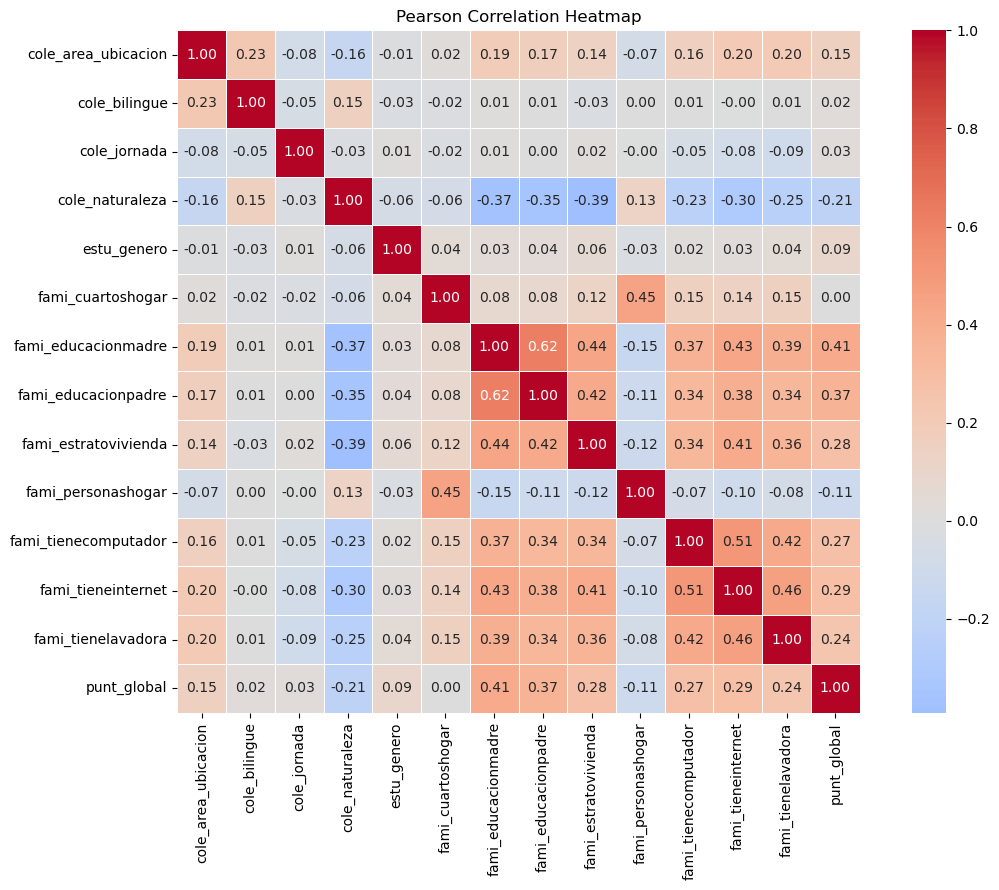

In [4]:
import seaborn as sns
import matplotlib.pyplot as plt

# Pearson correlation on numeric columns
corr = df.corr(numeric_only=True, method="pearson")

plt.figure(figsize=(12, 9))
sns.heatmap(
    corr,
    annot=True,      # set to False if too crowded
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    square=True,
    linewidths=0.5
)
plt.title("Pearson Correlation Heatmap")
plt.tight_layout()
plt.show()

In [10]:
# Regression with TensorFlow + CV hyperparameter tuning + MLflow
# - Defines target
# - Creates X/y and train/val/test splits
# - One-hot encodes nominal `cole_jornada`
# - Scales numeric features correctly inside each CV fold (no leakage)

import random
import numpy as np
import pandas as pd
import tensorflow as tf
import mlflow

from sklearn.model_selection import train_test_split, KFold, ParameterGrid
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score


In [11]:

mlflow.set_tracking_uri("http://127.0.0.1:5001")
experiment = mlflow.set_experiment("pregunta1DM-boyaca")

print("Tracking URI:", mlflow.get_tracking_uri())
print("Experiment ID:", experiment.experiment_id)

Tracking URI: http://127.0.0.1:5001
Experiment ID: 393762446855695624


In [19]:
import random
import numpy as np
import pandas as pd
import tensorflow as tf
import mlflow

from sklearn.model_selection import train_test_split, KFold, ParameterGrid
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# -----------------------------
# 0) Reproducibility
# -----------------------------
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

# -----------------------------
# 1) Target + cleanup
# -----------------------------
target = "punt_global"
nominal_col = "cole_jornada"

cols_to_drop = [
    "punt_ingles", "punt_matematicas", "punt_sociales_ciudadanas",
    "punt_c_naturales", "punt_lectura_critica", "estu_privado_libertad",
    "cole_nombre_establecimiento", "cole_mcpio_ubicacion",
    "cole_cod_mcpio_ubicacion", "cole_caracter", "periodo",
]

data = df.copy().drop(columns=cols_to_drop, errors="ignore")
data[target] = pd.to_numeric(data[target], errors="coerce")
data = data.dropna(subset=[target]).reset_index(drop=True)

if nominal_col in data.columns:
    data[nominal_col] = data[nominal_col].astype("string")

X = data.drop(columns=[target]).copy()
y = data[target].astype("float32").copy()

# -----------------------------
# 2) Train / val / test split
# -----------------------------
X_temp, X_test, y_temp, y_test = train_test_split(X, y, test_size=0.20, random_state=SEED)
X_train, X_val, y_train, y_val = train_test_split(X_temp, y_temp, test_size=0.25, random_state=SEED)
X_dev = pd.concat([X_train, X_val], axis=0).reset_index(drop=True)
y_dev = pd.concat([y_train, y_val], axis=0).reset_index(drop=True)

# -----------------------------
# 3) Helpers
# -----------------------------
def build_preprocess(X_ref):
    cat_cols = X_ref.select_dtypes(include=["object", "category", "string"]).columns.tolist()
    if nominal_col in X_ref.columns and nominal_col not in cat_cols:
        cat_cols.append(nominal_col)
    num_cols = [c for c in X_ref.columns if c not in cat_cols]

    numeric_pipe = Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
    ])
    categorical_pipe = Pipeline([
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False)),
    ])

    return ColumnTransformer([
        ("num", numeric_pipe, num_cols),
        ("cat", categorical_pipe, cat_cols),
    ])

def build_model(input_dim, hidden_layers=(64, 32), dropout_rate=0.1, learning_rate=5e-4):
    model = tf.keras.Sequential()
    model.add(tf.keras.layers.Input(shape=(input_dim,)))
    for units in hidden_layers:
        model.add(tf.keras.layers.Dense(units, activation="relu"))
        model.add(tf.keras.layers.Dropout(dropout_rate))
    model.add(tf.keras.layers.Dense(1, activation="linear"))
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=learning_rate),
        loss="mse",
        metrics=[tf.keras.metrics.MeanAbsoluteError(name="mae")]
    )
    return model

def reg_metrics(y_true, y_pred):
    mse = float(mean_squared_error(y_true, y_pred))
    mae = float(mean_absolute_error(y_true, y_pred))
    rmse = float(np.sqrt(mse))
    r2 = float(r2_score(y_true, y_pred))
    return mse, mae, rmse, r2

class MlflowEpochRegressionLogger(tf.keras.callbacks.Callback):
    def __init__(self, X_train, y_train, X_val, y_val, X_test, y_test):
        super().__init__()
        self.X_train, self.y_train = X_train, y_train
        self.X_val, self.y_val = X_val, y_val
        self.X_test, self.y_test = X_test, y_test

    def on_epoch_end(self, epoch, logs=None):
        step = epoch + 1
        p_tr = self.model.predict(self.X_train, verbose=1).ravel()
        p_va = self.model.predict(self.X_val, verbose=1).ravel()
        p_te = self.model.predict(self.X_test, verbose=1).ravel()

        tr_loss, tr_mae, tr_rmse, tr_r2 = reg_metrics(self.y_train, p_tr)
        va_loss, va_mae, va_rmse, va_r2 = reg_metrics(self.y_val, p_va)
        te_loss, te_mae, te_rmse, te_r2 = reg_metrics(self.y_test, p_te)

        mlflow.log_metric("train_loss", tr_loss, step=step)
        mlflow.log_metric("validation_loss", va_loss, step=step)
        mlflow.log_metric("test_loss", te_loss, step=step)

        mlflow.log_metric("train_mae", tr_mae, step=step)
        mlflow.log_metric("validation_mae", va_mae, step=step)
        mlflow.log_metric("test_mae", te_mae, step=step)

        mlflow.log_metric("train_rmse", tr_rmse, step=step)
        mlflow.log_metric("validation_rmse", va_rmse, step=step)
        mlflow.log_metric("test_rmse", te_rmse, step=step)

        mlflow.log_metric("train_r2", tr_r2, step=step)
        mlflow.log_metric("validation_r2", va_r2, step=step)
        mlflow.log_metric("test_r2", te_r2, step=step)

# -----------------------------
# 4) CV + one MLflow run per combination
# -----------------------------
param_grid = {
    "hidden_layers": [(32, 16), (64, 32), (128, 64, 32)],
    "dropout_rate": [0.1, 0.2],
    "learning_rate": [5e-4, 1e-3],
    "batch_size": [64],
    "epochs": [2],
}

skf = KFold(n_splits=2, shuffle=True, random_state=SEED)
experiment = mlflow.set_experiment("tf_regression_punt_global")

for params in ParameterGrid(param_grid):
    run_name = (
        f"reg_bs_{params['batch_size']}_"
        f"dr_{params['dropout_rate']}_"
        f"lr_{params['learning_rate']}_"
        f"hl_{'-'.join(map(str, params['hidden_layers']))}"
    )

    with mlflow.start_run(experiment_id=experiment.experiment_id, run_name=run_name):
        mlflow.log_params({
            "batch_size": params["batch_size"],
            "dropout_rate": params["dropout_rate"],
            "epochs": params["epochs"],
            "hidden_layers": str(params["hidden_layers"]),
            "learning_rate": params["learning_rate"],
            "n_splits": skf.n_splits,
            "sampling_method": "none",  # regression
            "target": target,
            "nominal_onehot": nominal_col,
        })

        # CV for selection signal (no fold metrics logged to MLflow)
        cv_rmse = []
        for tr_idx, va_idx in skf.split(X_dev):
            X_tr_cv, X_va_cv = X_dev.iloc[tr_idx], X_dev.iloc[va_idx]
            y_tr_cv, y_va_cv = y_dev.iloc[tr_idx].values, y_dev.iloc[va_idx].values

            prep_cv = build_preprocess(X_tr_cv)
            X_tr_cv_p = prep_cv.fit_transform(X_tr_cv).astype("float32")
            X_va_cv_p = prep_cv.transform(X_va_cv).astype("float32")

            tf.keras.backend.clear_session()
            m_cv = build_model(
                input_dim=X_tr_cv_p.shape[1],
                hidden_layers=params["hidden_layers"],
                dropout_rate=params["dropout_rate"],
                learning_rate=params["learning_rate"],
            )
            early_cv = tf.keras.callbacks.EarlyStopping(monitor="val_loss", patience=6, restore_best_weights=True)

            m_cv.fit(
                X_tr_cv_p, y_tr_cv,
                validation_data=(X_va_cv_p, y_va_cv),
                epochs=params["epochs"],
                batch_size=params["batch_size"],
                verbose=1,
                callbacks=[early_cv],
            )

            pred_cv = m_cv.predict(X_va_cv_p, verbose=1).ravel()
            cv_rmse.append(float(np.sqrt(mean_squared_error(y_va_cv, pred_cv))))

        mlflow.log_metric("cv_mean_rmse", float(np.mean(cv_rmse)))
        mlflow.log_metric("cv_std_rmse", float(np.std(cv_rmse)))

        # Final train/val/test for epoch curves in this run
        prep_final = build_preprocess(X_train)
        X_train_p = prep_final.fit_transform(X_train).astype("float32")
        X_val_p = prep_final.transform(X_val).astype("float32")
        X_test_p = prep_final.transform(X_test).astype("float32")

        y_train_np = y_train.to_numpy(dtype="float32")
        y_val_np = y_val.to_numpy(dtype="float32")
        y_test_np = y_test.to_numpy(dtype="float32")

        tf.keras.backend.clear_session()
        model = build_model(
            input_dim=X_train_p.shape[1],
            hidden_layers=params["hidden_layers"],
            dropout_rate=params["dropout_rate"],
            learning_rate=params["learning_rate"],
        )

        early = tf.keras.callbacks.EarlyStopping(monitor="val_loss", patience=8, restore_best_weights=True)
        epoch_logger = MlflowEpochRegressionLogger(X_train_p, y_train_np, X_val_p, y_val_np, X_test_p, y_test_np)

        model.fit(
            X_train_p, y_train_np,
            validation_data=(X_val_p, y_val_np),
            epochs=params["epochs"],
            batch_size=params["batch_size"],
            verbose=1,
            callbacks=[early, epoch_logger],
        )

        # Final summary metrics (optional)
        p_tr = model.predict(X_train_p, verbose=1).ravel()
        p_va = model.predict(X_val_p, verbose=1).ravel()
        p_te = model.predict(X_test_p, verbose=1).ravel()

        tr_loss, tr_mae, tr_rmse, tr_r2 = reg_metrics(y_train_np, p_tr)
        va_loss, va_mae, va_rmse, va_r2 = reg_metrics(y_val_np, p_va)
        te_loss, te_mae, te_rmse, te_r2 = reg_metrics(y_test_np, p_te)

        mlflow.log_metric("final_train_loss", tr_loss)
        mlflow.log_metric("final_validation_loss", va_loss)
        mlflow.log_metric("final_test_loss", te_loss)
        mlflow.log_metric("final_train_mae", tr_mae)
        mlflow.log_metric("final_validation_mae", va_mae)
        mlflow.log_metric("final_test_mae", te_mae)
        mlflow.log_metric("final_train_rmse", tr_rmse)
        mlflow.log_metric("final_validation_rmse", va_rmse)
        mlflow.log_metric("final_test_rmse", te_rmse)
        mlflow.log_metric("final_train_r2", tr_r2)
        mlflow.log_metric("final_validation_r2", va_r2)
        mlflow.log_metric("final_test_r2", te_r2)

print("Done: one MLflow run per hyperparameter combination, no fold-level logs, epoch curves included.")

Epoch 1/2
626/626 ━━━━━━━━━━━━━━━━━━━━ 10s 15ms/step - loss: 64325.4531 - mae: 249.3105 - val_loss: 50981.2695 - val_mae: 219.7999
Epoch 2/2
626/626 ━━━━━━━━━━━━━━━━━━━━ 9s 15ms/step - loss: 36886.9453 - mae: 179.1787 - val_loss: 19701.6699 - val_mae: 133.1233
1251/1251 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step
Epoch 1/2
626/626 ━━━━━━━━━━━━━━━━━━━━ 10s 15ms/step - loss: 64199.1758 - mae: 247.2528 - val_loss: 51599.1016 - val_mae: 210.0814
Epoch 2/2
626/626 ━━━━━━━━━━━━━━━━━━━━ 9s 14ms/step - loss: 41183.1367 - mae: 178.2986 - val_loss: 25553.3828 - val_mae: 138.1715
1251/1251 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step
Epoch 1/2
1876/1876 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step
626/626 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step
626/626 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
938/938 ━━━━━━━━━━━━━━━━━━━━ 18s 18ms/step - loss: 60098.9570 - mae: 238.1709 - val_loss: 42362.1836 - val_mae: 194.0915
Epoch 2/2
1876/1876 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step
626/626 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step
626/626 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step
9

2026/05/25 01:08:46 INFO mlflow.tracking._tracking_service.client: 🏃 View run reg_bs_64_dr_0.1_lr_0.0005_hl_32-16 at: http://127.0.0.1:5001/#/experiments/166752165488137542/runs/8448dc449af041ab829b63e292776afe.
2026/05/25 01:08:46 INFO mlflow.tracking._tracking_service.client: 🧪 View experiment at: http://127.0.0.1:5001/#/experiments/166752165488137542.


Epoch 1/2
626/626 ━━━━━━━━━━━━━━━━━━━━ 10s 14ms/step - loss: 48177.5781 - mae: 205.8934 - val_loss: 11839.8154 - val_mae: 100.1167
Epoch 2/2
626/626 ━━━━━━━━━━━━━━━━━━━━ 9s 14ms/step - loss: 13648.1104 - mae: 84.9842 - val_loss: 2134.4517 - val_mae: 36.9341
1251/1251 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step
Epoch 1/2
626/626 ━━━━━━━━━━━━━━━━━━━━ 10s 14ms/step - loss: 43523.0664 - mae: 186.2659 - val_loss: 7100.0732 - val_mae: 67.0965
Epoch 2/2
626/626 ━━━━━━━━━━━━━━━━━━━━ 9s 14ms/step - loss: 8280.2285 - mae: 67.6087 - val_loss: 2011.8286 - val_mae: 35.7839
1251/1251 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step
Epoch 1/2
1876/1876 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step
626/626 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step
626/626 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step
938/938 ━━━━━━━━━━━━━━━━━━━━ 16s 16ms/step - loss: 31635.9238 - mae: 149.5514 - val_loss: 1940.4106 - val_mae: 35.1669
Epoch 2/2
1876/1876 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step
626/626 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
626/626 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step
938/938 ━━━━

2026/05/25 01:10:06 INFO mlflow.tracking._tracking_service.client: 🏃 View run reg_bs_64_dr_0.1_lr_0.001_hl_32-16 at: http://127.0.0.1:5001/#/experiments/166752165488137542/runs/427c701d1f6d44cda8261c44ccd61ff8.
2026/05/25 01:10:06 INFO mlflow.tracking._tracking_service.client: 🧪 View experiment at: http://127.0.0.1:5001/#/experiments/166752165488137542.


Epoch 1/2
626/626 ━━━━━━━━━━━━━━━━━━━━ 10s 14ms/step - loss: 57892.5859 - mae: 234.4055 - val_loss: 32341.5508 - val_mae: 174.2234
Epoch 2/2
626/626 ━━━━━━━━━━━━━━━━━━━━ 9s 14ms/step - loss: 18685.7012 - mae: 113.0978 - val_loss: 3101.0034 - val_mae: 45.2326
1251/1251 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step
Epoch 1/2
626/626 ━━━━━━━━━━━━━━━━━━━━ 9s 14ms/step - loss: 53592.4492 - mae: 223.0989 - val_loss: 22422.7266 - val_mae: 140.5141
Epoch 2/2
626/626 ━━━━━━━━━━━━━━━━━━━━ 8s 13ms/step - loss: 11512.7217 - mae: 84.8571 - val_loss: 2081.2864 - val_mae: 36.4382
1251/1251 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step
Epoch 1/2
1876/1876 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step
626/626 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step
626/626 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step
938/938 ━━━━━━━━━━━━━━━━━━━━ 16s 16ms/step - loss: 47921.8516 - mae: 204.5340 - val_loss: 14096.5449 - val_mae: 111.3207
Epoch 2/2
1876/1876 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step
626/626 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step
626/626 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step
938/938

...

Epoch 1/2
626/626 ━━━━━━━━━━━━━━━━━━━━ 12s 17ms/step - loss: 62385.1172 - mae: 205.6268 - val_loss: 2725.6768 - val_mae: 41.8854
Epoch 2/2
626/626 ━━━━━━━━━━━━━━━━━━━━ 10s 17ms/step - loss: 21045.4004 - mae: 102.4165 - val_loss: 2076.8848 - val_mae: 36.3812
1251/1251 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step
Epoch 1/2
626/626 ━━━━━━━━━━━━━━━━━━━━ 14s 21ms/step - loss: 37241.7461 - mae: 160.4037 - val_loss: 1956.9011 - val_mae: 35.3569
Epoch 2/2
626/626 ━━━━━━━━━━━━━━━━━━━━ 12s 20ms/step - loss: 9533.8955 - mae: 72.7635 - val_loss: 1686.4130 - val_mae: 32.9140
1251/1251 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step
Epoch 1/2
1876/1876 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step
626/626 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
626/626 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step
938/938 ━━━━━━━━━━━━━━━━━━━━ 22s 22ms/step - loss: 60531.1289 - mae: 189.0700 - val_loss: 2643.4590 - val_mae: 40.9521
Epoch 2/2
1876/1876 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step
626/626 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step
626/626 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
938/938 ━━━

2026/05/25 01:24:47 INFO mlflow.tracking._tracking_service.client: 🏃 View run reg_bs_64_dr_0.2_lr_0.0005_hl_128-64-32 at: http://127.0.0.1:5001/#/experiments/166752165488137542/runs/17dac791bc4440039f18d47fedf21c95.
2026/05/25 01:24:47 INFO mlflow.tracking._tracking_service.client: 🧪 View experiment at: http://127.0.0.1:5001/#/experiments/166752165488137542.


Epoch 1/2
626/626 ━━━━━━━━━━━━━━━━━━━━ 13s 19ms/step - loss: 37516.8984 - mae: 148.4659 - val_loss: 2606.5505 - val_mae: 40.7484
Epoch 2/2
626/626 ━━━━━━━━━━━━━━━━━━━━ 14s 22ms/step - loss: 7387.3804 - mae: 66.3340 - val_loss: 2119.9387 - val_mae: 36.7614
1251/1251 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step
Epoch 1/2
626/626 ━━━━━━━━━━━━━━━━━━━━ 16s 23ms/step - loss: 18789.3027 - mae: 103.6341 - val_loss: 1746.1991 - val_mae: 33.5020
Epoch 2/2
626/626 ━━━━━━━━━━━━━━━━━━━━ 14s 23ms/step - loss: 5106.9194 - mae: 56.0040 - val_loss: 1693.0240 - val_mae: 32.9688
1251/1251 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step
Epoch 1/2
1876/1876 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step
626/626 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step
626/626 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step
938/938 ━━━━━━━━━━━━━━━━━━━━ 38s 39ms/step - loss: 35566.7812 - mae: 137.8964 - val_loss: 1966.3496 - val_mae: 35.4099
Epoch 2/2
1876/1876 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step
626/626 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step
626/626 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step
938/938 ━━━━━

2026/05/25 01:26:59 INFO mlflow.tracking._tracking_service.client: 🏃 View run reg_bs_64_dr_0.2_lr_0.001_hl_128-64-32 at: http://127.0.0.1:5001/#/experiments/166752165488137542/runs/99b9bf6b008743b0b16573bd56e1cb2c.
2026/05/25 01:26:59 INFO mlflow.tracking._tracking_service.client: 🧪 View experiment at: http://127.0.0.1:5001/#/experiments/166752165488137542.


Done: one MLflow run per hyperparameter combination, no fold-level logs, epoch curves included.


## Probar Red sin MLflow

In [4]:
import random
import numpy as np
import pandas as pd
import tensorflow as tf
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, KFold, ParameterGrid
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

In [8]:
import random
import numpy as np
import pandas as pd
import tensorflow as tf
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, KFold, ParameterGrid
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# -----------------------------
# 0) Reproducibility
# -----------------------------
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

# -----------------------------
# 1) Target + predictors
# -----------------------------
target = "punt_global"
nominal_col = "cole_jornada"

cols_to_drop = [
    "punt_ingles", "punt_matematicas", "punt_sociales_ciudadanas",
    "punt_c_naturales", "punt_lectura_critica", "estu_privado_libertad",
    "cole_nombre_establecimiento", "cole_mcpio_ubicacion",
    "cole_cod_mcpio_ubicacion", "cole_caracter", "periodo",
]

data = df.copy().drop(columns=cols_to_drop, errors="ignore")
data[target] = pd.to_numeric(data[target], errors="coerce")
data = data.dropna(subset=[target]).reset_index(drop=True)

if nominal_col in data.columns:
    data[nominal_col] = data[nominal_col].astype("string")

X = data.drop(columns=[target]).copy()
y = data[target].astype("float32").copy()

# 80% dev (CV) / 20% test
X_dev, X_test, y_dev, y_test = train_test_split(X, y, test_size=0.20, random_state=SEED)

# -----------------------------
# 2) Helpers
# -----------------------------
def make_preprocessor(X_ref):
    cat_cols = X_ref.select_dtypes(include=["object", "category", "string"]).columns.tolist()
    if nominal_col in X_ref.columns and nominal_col not in cat_cols:
        cat_cols.append(nominal_col)
    num_cols = [c for c in X_ref.columns if c not in cat_cols]

    return ColumnTransformer([
        ("num", Pipeline([
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler", StandardScaler()),
        ]), num_cols),
        ("cat", Pipeline([
            ("imputer", SimpleImputer(strategy="most_frequent")),
            ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False)),
        ]), cat_cols),
    ])

def build_model(input_dim, hidden_layers=(128, 64), dropout_rate=0.2, learning_rate=5e-4):
    model = tf.keras.Sequential([tf.keras.layers.Input(shape=(input_dim,))])
    for u in hidden_layers:
        model.add(tf.keras.layers.Dense(u, activation="relu"))
        model.add(tf.keras.layers.Dropout(dropout_rate))
    model.add(tf.keras.layers.Dense(1, activation="linear"))
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=learning_rate),
        loss="mse",
        metrics=[tf.keras.metrics.MeanSquaredError(name="mse")]
    )
    return model

class SklearnR2Callback(tf.keras.callbacks.Callback):
    def __init__(self, X_tr, y_tr, X_va, y_va, print_each_epoch=False):
        super().__init__()
        self.X_tr, self.y_tr = X_tr, y_tr
        self.X_va, self.y_va = X_va, y_va
        self.print_each_epoch = print_each_epoch
        self.train_r2, self.val_r2 = [], []

    def on_epoch_end(self, epoch, logs=None):
        p_tr = self.model.predict(self.X_tr, verbose=0).ravel()
        p_va = self.model.predict(self.X_va, verbose=0).ravel()
        tr_r2 = r2_score(self.y_tr, p_tr)
        va_r2 = r2_score(self.y_va, p_va)
        self.train_r2.append(tr_r2)
        self.val_r2.append(va_r2)
        if logs is not None:
            logs["train_r2_sklearn"] = tr_r2
            logs["val_r2_sklearn"] = va_r2
        if self.print_each_epoch:
            print(f" | train_r2={tr_r2:.4f} val_r2={va_r2:.4f}")

def pad_nan(arr, n):
    out = np.full(n, np.nan, dtype=float)
    out[:len(arr)] = arr
    return out

# -----------------------------
# 3) CV hyperparameter tuning
# -----------------------------
EPOCHS = 100
N_SPLITS = 5
PATIENCE = 10

param_grid = {
    "hidden_layers": [(64, 32), (128, 64), (128, 64, 32)],
    "batch_size": [64, 128, 256],
    "learning_rate": [1e-3, 5e-4, 1e-4],
}

kf = KFold(n_splits=N_SPLITS, shuffle=True, random_state=SEED)

best_params, best_score, best_curves = None, np.inf, None

for params in ParameterGrid(param_grid):
    fold_loss, fold_val_loss, fold_mse, fold_val_mse, fold_r2, fold_val_r2 = [], [], [], [], [], []
    best_epoch_val_mse = []

    for tr_idx, va_idx in kf.split(X_dev):
        X_tr, X_va = X_dev.iloc[tr_idx], X_dev.iloc[va_idx]
        y_tr, y_va = y_dev.iloc[tr_idx].values, y_dev.iloc[va_idx].values

        prep = make_preprocessor(X_tr)
        X_tr_p = prep.fit_transform(X_tr).astype("float32")
        X_va_p = prep.transform(X_va).astype("float32")

        tf.keras.backend.clear_session()
        model = build_model(
            input_dim=X_tr_p.shape[1],
            hidden_layers=params["hidden_layers"],
            dropout_rate=0.2,
            learning_rate=params["learning_rate"],
        )

        r2_cb = SklearnR2Callback(X_tr_p, y_tr, X_va_p, y_va, print_each_epoch=False)
        es = tf.keras.callbacks.EarlyStopping(
            monitor="val_loss", patience=PATIENCE, restore_best_weights=True
        )

        h = model.fit(
            X_tr_p, y_tr,
            validation_data=(X_va_p, y_va),
            epochs=EPOCHS,
            batch_size=params["batch_size"],
            verbose=1,
            callbacks=[r2_cb, es],
        )

        fold_loss.append(np.array(h.history["loss"]))
        fold_val_loss.append(np.array(h.history["val_loss"]))
        fold_mse.append(np.array(h.history["mse"]))
        fold_val_mse.append(np.array(h.history["val_mse"]))
        fold_r2.append(np.array(r2_cb.train_r2))
        fold_val_r2.append(np.array(r2_cb.val_r2))
        best_epoch_val_mse.append(float(np.min(h.history["val_mse"])))

    max_len = max(len(x) for x in fold_loss)
    mean_train_loss = np.nanmean(np.vstack([pad_nan(x, max_len) for x in fold_loss]), axis=0)
    mean_val_loss = np.nanmean(np.vstack([pad_nan(x, max_len) for x in fold_val_loss]), axis=0)
    mean_train_mse = np.nanmean(np.vstack([pad_nan(x, max_len) for x in fold_mse]), axis=0)
    mean_val_mse = np.nanmean(np.vstack([pad_nan(x, max_len) for x in fold_val_mse]), axis=0)
    mean_train_r2 = np.nanmean(np.vstack([pad_nan(x, max_len) for x in fold_r2]), axis=0)
    mean_val_r2 = np.nanmean(np.vstack([pad_nan(x, max_len) for x in fold_val_r2]), axis=0)

    combo_name = f"hl={params['hidden_layers']}, bs={params['batch_size']}, lr={params['learning_rate']}"
    print(f"\n=== {combo_name} ===")
    for ep in range(max_len):
        print(
            f"Epoch {ep+1:03d} | "
            f"train_loss={mean_train_loss[ep]:.4f} val_loss={mean_val_loss[ep]:.4f} | "
            f"train_mse={mean_train_mse[ep]:.4f} val_mse={mean_val_mse[ep]:.4f} | "
            f"train_r2={mean_train_r2[ep]:.4f} val_r2={mean_val_r2[ep]:.4f}"
        )

    score = float(np.mean(best_epoch_val_mse))
    if score < best_score:
        best_score = score
        best_params = params
        best_curves = {
            "train_loss": mean_train_loss,
            "val_loss": mean_val_loss,
            "train_mse": mean_train_mse,
            "val_mse": mean_val_mse,
            "train_r2": mean_train_r2,
            "val_r2": mean_val_r2,
        }

print("\nBest hyperparameters:", best_params)
print(f"Best CV score (mean best-fold val MSE): {best_score:.6f}")

# -----------------------------
# 4) Plot best CV curves
# -----------------------------
epochs_axis = np.arange(1, len(best_curves["train_loss"]) + 1)

plt.figure(figsize=(15, 4))
plt.subplot(1, 3, 1)
plt.plot(epochs_axis, best_curves["train_loss"], label="Train Loss")
plt.plot(epochs_axis, best_curves["val_loss"], label="Validation Loss")
plt.xlabel("Epoch"); plt.ylabel("Loss"); plt.title("Loss vs Epoch"); plt.legend()

plt.subplot(1, 3, 2)
plt.plot(epochs_axis, best_curves["train_mse"], label="Train MSE")
plt.plot(epochs_axis, best_curves["val_mse"], label="Validation MSE")
plt.xlabel("Epoch"); plt.ylabel("MSE"); plt.title("MSE vs Epoch"); plt.legend()

plt.subplot(1, 3, 3)
plt.plot(epochs_axis, best_curves["train_r2"], label="Train R2 (sklearn)")
plt.plot(epochs_axis, best_curves["val_r2"], label="Validation R2 (sklearn)")
plt.xlabel("Epoch"); plt.ylabel("R2"); plt.title("R2 vs Epoch"); plt.legend()

plt.tight_layout()
plt.show()

# -----------------------------
# 5) Final model on full 80%, test on 20%
# -----------------------------
prep_final = make_preprocessor(X_dev)
X_dev_p = prep_final.fit_transform(X_dev).astype("float32")
X_test_p = prep_final.transform(X_test).astype("float32")
y_dev_np = y_dev.to_numpy(dtype="float32")
y_test_np = y_test.to_numpy(dtype="float32")

tf.keras.backend.clear_session()
final_model = build_model(
    input_dim=X_dev_p.shape[1],
    hidden_layers=best_params["hidden_layers"],
    dropout_rate=0.2,
    learning_rate=best_params["learning_rate"],
)

# Small validation split only for early stopping
es_final = tf.keras.callbacks.EarlyStopping(
    monitor="val_loss", patience=PATIENCE, restore_best_weights=True
)

history_final = final_model.fit(
    X_dev_p, y_dev_np,
    validation_split=0.1,
    epochs=EPOCHS,
    batch_size=best_params["batch_size"],
    verbose=1,
    callbacks=[es_final],
)

y_test_pred = final_model.predict(X_test_p, verbose=0).ravel()
test_mse = mean_squared_error(y_test_np, y_test_pred)
test_rmse = np.sqrt(test_mse)
test_mae = mean_absolute_error(y_test_np, y_test_pred)
test_r2 = r2_score(y_test_np, y_test_pred)

print("\nTest metrics:")
print(f"Test MSE : {test_mse:.4f}")
print(f"Test RMSE: {test_rmse:.4f}")
print(f"Test MAE : {test_mae:.4f}")
print(f"Test R2  : {test_r2:.4f}")

Epoch 1/100
1001/1001 ━━━━━━━━━━━━━━━━━━━━ 13s 12ms/step - loss: 33695.7852 - mse: 33695.7852 - val_loss: 3057.2373 - val_mse: 3057.2373 - train_r2_sklearn: -0.4984 - val_r2_sklearn: -0.4719
Epoch 2/100
1001/1001 ━━━━━━━━━━━━━━━━━━━━ 11s 11ms/step - loss: 8252.9248 - mse: 8252.9248 - val_loss: 2019.5570 - val_mse: 2019.5570 - train_r2_sklearn: 0.0214 - val_r2_sklearn: 0.0277
Epoch 3/100
1001/1001 ━━━━━━━━━━━━━━━━━━━━ 11s 11ms/step - loss: 4310.9004 - mse: 4310.9004 - val_loss: 1771.7772 - val_mse: 1771.7772 - train_r2_sklearn: 0.1405 - val_r2_sklearn: 0.1470
Epoch 4/100
1001/1001 ━━━━━━━━━━━━━━━━━━━━ 11s 11ms/step - loss: 4014.0081 - mse: 4014.0081 - val_loss: 1765.3199 - val_mse: 1765.3199 - train_r2_sklearn: 0.1441 - val_r2_sklearn: 0.1501
Epoch 5/100
1001/1001 ━━━━━━━━━━━━━━━━━━━━ 11s 11ms/step - loss: 3953.6787 - mse: 3953.6787 - val_loss: 1779.4420 - val_mse: 1779.4420 - train_r2_sklearn: 0.1379 - val_r2_sklearn: 0.1433
Epoch 6/100
1001/1001 ━━━━━━━━━━━━━━━━━━━━ 11s 11ms/step - lo

KeyboardInterrupt: 

## Diagnostico NNs

El modelo como está planteado tiene muchas limitaciones de poder predictivo a pesar de muchas pasadas sobre los datos, se buscan alternativas sobre otros modelos más simples e interpretables para encontrar la fuente como regresión lineal con OLS

In [8]:
df.dropna(inplace=True)
df.shape

(96150, 14)

In [9]:
from sklearn.model_selection import train_test_split

# Define target variable (y) and features (X)
y = df['punt_global']
X = df.drop(columns=['punt_global'])

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f'X_train shape: {X_train.shape}')
print(f'X_test shape: {X_test.shape}')
print(f'y_train shape: {y_train.shape}')
print(f'y_test shape: {y_test.shape}')

X_train shape: (76920, 13)
X_test shape: (19230, 13)
y_train shape: (76920,)
y_test shape: (19230,)


In [13]:
import statsmodels.api as sm
# Identify boolean columns for conversion
bool_cols_train = X_train.select_dtypes(include='bool').columns
bool_cols_test = X_test.select_dtypes(include='bool').columns

# Convert boolean columns to integers (0 or 1) for statsmodels
X_train[bool_cols_train] = X_train[bool_cols_train].astype(int)
X_test[bool_cols_test] = X_test[bool_cols_test].astype(int)

# Add a constant to the independent variables for OLS regression
X_train_ols_fixed = sm.add_constant(X_train)
X_test_ols_fixed = sm.add_constant(X_test)

# Create and fit the OLS model
ols_model_fixed = sm.OLS(y_train, X_train_ols_fixed)
ols_results_fixed = ols_model_fixed.fit()

# Print the OLS regression summary with significance (p-values)
print("\n--- OLS Regression Results (with p-values and errors) ---")
print(ols_results_fixed.summary())

# Evaluate OLS model on the test set
ols_predictions_fixed = ols_results_fixed.predict(X_test_ols_fixed)
ols_r2_fixed = r2_score(y_test, ols_predictions_fixed)
ols_mse_fixed = mean_squared_error(y_test, ols_predictions_fixed)

print(f'\nFixed OLS R-squared on test set: {ols_r2_fixed:.4f}')
print(f'Fixed OLS Mean Squared Error on test set: {ols_mse_fixed:.2f}')


--- OLS Regression Results (with p-values and errors) ---
                            OLS Regression Results                            
Dep. Variable:            punt_global   R-squared:                       0.221
Model:                            OLS   Adj. R-squared:                  0.221
Method:                 Least Squares   F-statistic:                     1680.
Date:                Mon, 25 May 2026   Prob (F-statistic):               0.00
Time:                        14:56:58   Log-Likelihood:            -3.9330e+05
No. Observations:               76920   AIC:                         7.866e+05
Df Residuals:                   76906   BIC:                         7.868e+05
Df Model:                          13                                         
Covariance Type:            nonrobust                                         
                           coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------


--- OLS Performance Metrics ---
Train R²:   0.2212
Train RMSE: 40.21
Test R²:    0.2213
Test RMSE:  40.51


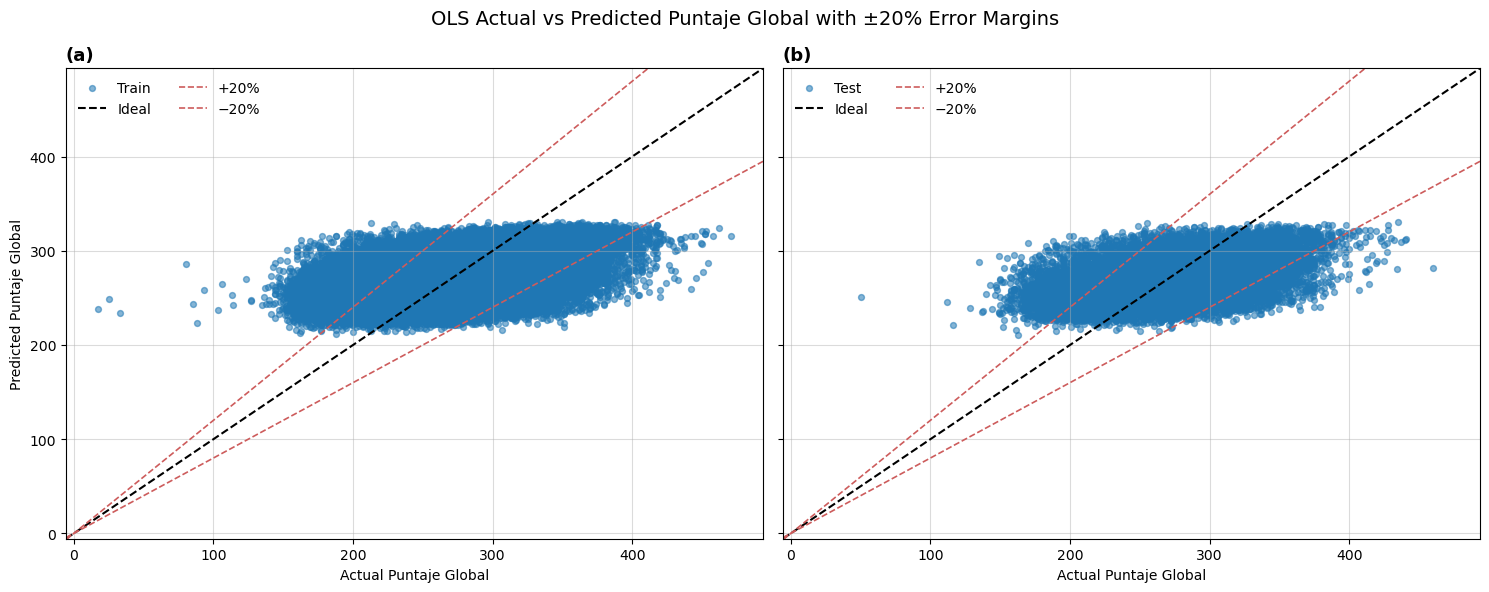

In [18]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import r2_score, mean_squared_error

# -----------------------------
# Predictions
# -----------------------------
ols_predictions_train = ols_results_fixed.predict(X_train_ols_fixed)
ols_predictions_test = ols_results_fixed.predict(X_test_ols_fixed)

# -----------------------------
# Metrics
# -----------------------------
ols_r2_train = r2_score(y_train, ols_predictions_train)
ols_rmse_train = np.sqrt(mean_squared_error(y_train, ols_predictions_train))

ols_r2_test = r2_score(y_test, ols_predictions_test)
ols_rmse_test = np.sqrt(mean_squared_error(y_test, ols_predictions_test))

print("\n--- OLS Performance Metrics ---")
print(f"Train R²:   {ols_r2_train:.4f}")
print(f"Train RMSE: {ols_rmse_train:.2f}")
print(f"Test R²:    {ols_r2_test:.4f}")
print(f"Test RMSE:  {ols_rmse_test:.2f}")

# -----------------------------
# Common limits
# -----------------------------
min_value = min(
    y_train.min(),
    y_test.min(),
    ols_predictions_train.min(),
    ols_predictions_test.min()
)

max_value = max(
    y_train.max(),
    y_test.max(),
    ols_predictions_train.max(),
    ols_predictions_test.max()
)

# Add a small visual margin
padding = 0.05 * (max_value - min_value)
min_plot = min_value - padding
max_plot = max_value + padding

x_line = np.linspace(min_plot, max_plot, 300)

ideal_line = x_line
upper_20 = 1.20 * x_line
lower_20 = 0.80 * x_line

# -----------------------------
# Plot
# -----------------------------
fig, axes = plt.subplots(1, 2, figsize=(15, 6), sharex=True, sharey=True)

# =============================
# (a) Train
# =============================
axes[0].scatter(
    y_train,
    ols_predictions_train,
    alpha=0.55,
    s=18,
    label="Train"
)

axes[0].plot(
    x_line,
    ideal_line,
    linestyle="--",
    linewidth=1.5,
    color="black",
    label="Ideal"
)

axes[0].plot(
    x_line,
    upper_20,
    linestyle="--",
    linewidth=1.2,
    color="indianred",
    label="+20%"
)

axes[0].plot(
    x_line,
    lower_20,
    linestyle="--",
    linewidth=1.2,
    color="indianred",
    label="−20%"
)

axes[0].set_title("(a)", loc="left", fontsize=13, fontweight="bold")
axes[0].set_xlabel("Actual Puntaje Global")
axes[0].set_ylabel("Predicted Puntaje Global")
axes[0].legend(loc="upper left", frameon=False, ncol=2)
axes[0].grid(True, alpha=0.45)

# =============================
# (b) Test
# =============================
axes[1].scatter(
    y_test,
    ols_predictions_test,
    alpha=0.55,
    s=18,
    label="Test"
)

axes[1].plot(
    x_line,
    ideal_line,
    linestyle="--",
    linewidth=1.5,
    color="black",
    label="Ideal"
)

axes[1].plot(
    x_line,
    upper_20,
    linestyle="--",
    linewidth=1.2,
    color="indianred",
    label="+20%"
)

axes[1].plot(
    x_line,
    lower_20,
    linestyle="--",
    linewidth=1.2,
    color="indianred",
    label="−20%"
)

axes[1].set_title("(b)", loc="left", fontsize=13, fontweight="bold")
axes[1].set_xlabel("Actual Puntaje Global")
axes[1].legend(loc="upper left", frameon=False, ncol=2)
axes[1].grid(True, alpha=0.45)

# -----------------------------
# Same limits for both plots
# -----------------------------
for ax in axes:
    ax.set_xlim(min_plot, max_plot)
    ax.set_ylim(min_plot, max_plot)

plt.suptitle(
    "OLS Actual vs Predicted Puntaje Global with ±20% Error Margins",
    fontsize=14
)

plt.tight_layout()
plt.show()